In [ ]:
# Example: Clone dataset (replace URL with actual GitHub dataset URL)
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git


Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163235, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 163235 (delta 2), reused 0 (delta 0), pack-reused 163229 (from 1)
Receiving objects: 100% (163235/163235), 2.00 GiB | 27.12 MiB/s, done.
Resolving deltas: 100% (101/101), done.
Updating files: 100% (182401/182401), done.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Adjust path if necessary
data_dir = "/content/PlantVillage-Dataset/raw/color"


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize images to [0, 1]
    validation_split=0.2,  # 80% train, 20% validation
    rotation_range=20,  # Random rotations to augment the data
    zoom_range=0.15,  # Zoom augmentation
    width_shift_range=0.1,  # Horizontal shift
    height_shift_range=0.1,  # Vertical shift
    shear_range=0.15,  # Shear transformations
    horizontal_flip=True,  # Flip images randomly
    fill_mode="nearest"
)



In [ ]:
img_height, img_width = 128, 128
batch_size = 32

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),  # Resize images for MobileNetV2 input
    batch_size=batch_size,
    class_mode='categorical',  # Since we are doing multi-class classification
    subset='training'  # Use the training subset
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),  # Resize images for MobileNetV2 input
    batch_size=batch_size,
    class_mode='categorical',  # Multi-class classification
    subset='validation'  # Use the validation subset
)




Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model


base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # Freeze base
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Unfreeze the last few layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
epochs = 10

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 341s 238ms/step - accuracy: 0.7455 - loss: 0.9570 - val_accuracy: 0.6247 - val_loss: 2.5757
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 288s 212ms/step - accuracy: 0.9042 - loss: 0.3429 - val_accuracy: 0.8769 - val_loss: 0.5212
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 259s 190ms/step - accuracy: 0.9294 - loss: 0.2473 - val_accuracy: 0.9462 - val_loss: 0.2013
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 254s 187ms/step - accuracy: 0.9393 - loss: 0.2124 - val_accuracy: 0.9528 - val_loss: 0.2114
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 252s 186ms/step - accuracy: 0.9475 - loss: 0.1896 - val_accuracy: 0.9430 - val_loss: 0.2502
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 261s 185ms/step - accuracy: 0.9516 - loss: 0.1716 - val_accuracy: 0.9530 - val_loss: 0.1846
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 253s 186ms/step - accuracy: 0.9555 - loss: 0.1586 - val_accuracy: 0.9549 - val_loss: 0.1698
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 250s 184ms/step - ac

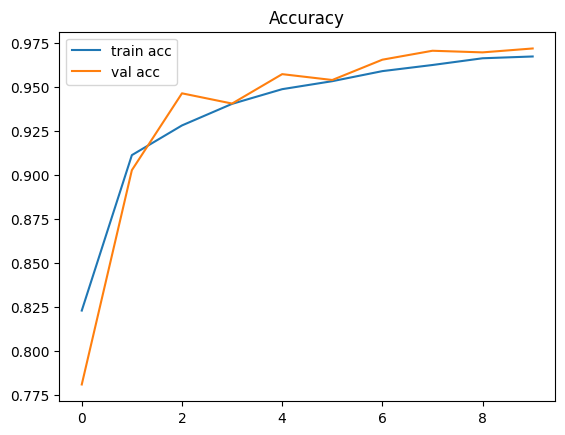

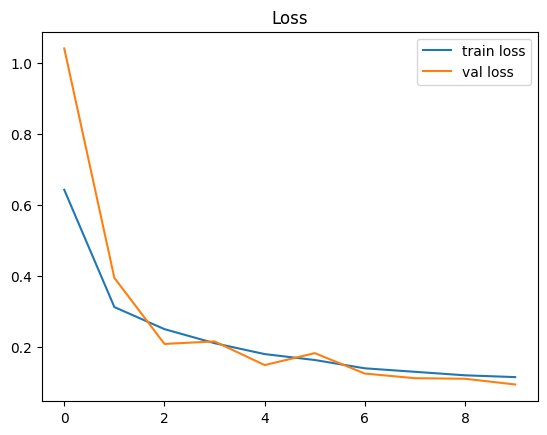

In [ ]:
# Plot accuracy and loss curves
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()


In [ ]:
# Predict on validation set
val_generator.reset()
preds = model.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

# Classification Report
print(classification_report(y_true, y_pred, target_names=list(val_generator.class_indices.keys())))


340/340 ━━━━━━━━━━━━━━━━━━━━ 66s 184ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.00      0.00      0.00       126
                                 Apple___Black_rot       0.02      0.02      0.02       124
                          Apple___Cedar_apple_rust       0.00      0.00      0.00        55
                                   Apple___healthy       0.02      0.02      0.02       329
                               Blueberry___healthy       0.01      0.01      0.01       300
          Cherry_(including_sour)___Powdery_mildew       0.03      0.03      0.03       210
                 Cherry_(including_sour)___healthy       0.00      0.00      0.00       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.00      0.00      0.00       102
                       Corn_(maize)___Common_rust_       0.01      0.01      0.01       238
               Corn_(maize)___North

In [ ]:
from tensorflow.keras.preprocessing import image
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]


Saving apple_img.jpg to apple_img.jpg


In [ ]:
# Get uploaded filename

# Load and preprocess
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalize


In [ ]:
# Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)[0]
class_labels = list(train_generator.class_indices.keys())

# Output
print("Predicted Disease Class:", class_labels[predicted_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Disease Class: Apple___Black_rot


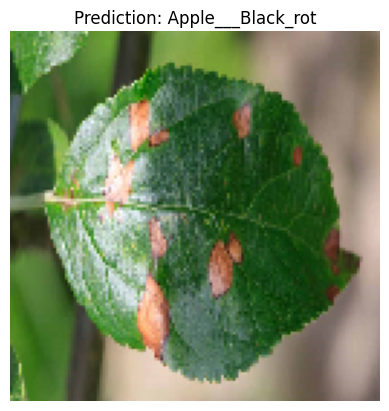

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {class_labels[predicted_class]}")
plt.show()


In [ ]:
model.save("cropcare_final.h5")


In [ ]:
from google.colab import files
files.download("cropcare_final.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

# Step 1: Invert the class_indices dictionary to map index → label
labels = {v: k for k, v in train_generator.class_indices.items()}

# Step 2: Save the dictionary as a .pkl file
with open('class_labels.pkl', 'wb') as f:
    pickle.dump(labels, f)


In [ ]:
from google.colab import files
files.download('class_labels.pkl')
